# Task 8: Generative AI and Deep Learning Model Optimization

## Objective
To explore generative deep learning models and deployment-oriented optimization techniques for efficient inference.

## Reference Dataset
**CIFAR-10 Dataset**

> This practical uses CIFAR-10 so that the dataset and image dimensions remain consistent with Task 3. CIFAR-10 contains coloured images of size 32 × 32 × 3 belonging to 10 classes.

## 1. Objectives

- To load and preprocess the CIFAR-10 dataset.
- To implement a Deep Convolutional Generative Adversarial Network (DCGAN).
- To generate synthetic images using the trained GAN.
- To observe GAN training behaviour and generated outputs.
- To apply model pruning to a CNN classifier.
- To apply post-training quantization and compression.
- To implement knowledge distillation using a teacher and student CNN.
- To compare model size, accuracy and inference performance.

## 2. Dataset Used

The **CIFAR-10** dataset is used for this practical.

For consistency with Task 3:
- Training subset: 4,000 images
- Validation subset: 2,000 images
- Test images: 10,000 images
- Image dimensions: 32 × 32 × 3
- Number of classes: 10

For the DCGAN, the 4,000-image training subset is normalized to the range **[-1, 1]**, which is suitable for a generator using `tanh` output.

## 3. Theory

### Generative Adversarial Network (GAN)
A GAN consists of two neural networks:

1. **Generator** – creates synthetic images from random noise.
2. **Discriminator** – distinguishes real images from generated images.

The two networks compete during training. The generator tries to produce realistic images, while the discriminator tries to identify fake images.

### DCGAN
A Deep Convolutional GAN uses convolutional and transposed-convolutional layers to learn image structure. It is suitable for image generation tasks such as CIFAR-10.

### Model Optimization
Deep learning models can be optimized for deployment by reducing their computational and storage requirements.

- **Pruning:** removes or zeros less important weights.
- **Quantization:** represents model parameters using lower precision, such as INT8.
- **Compression:** stores the model in a compact representation.
- **Knowledge Distillation:** trains a smaller student model using information learned by a larger teacher model.

The optimized models are compared using model size, accuracy and inference time.

In [2]:
%pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.9 MB 656.4 kB/s eta 0:00:15
   ---------------------------------------- 0.1/9.9 MB 656.4 kB/s eta 0:00:15
   ---------------------------------------- 0.1/9.9 MB 658.7 kB/s eta 0:00:15
    --------------------------------------- 0.2/9.9 MB 892.5 kB/s eta 0:00:11
   - -------------------------------------- 0.3/9.9 MB 983.9 kB/s eta 0:00:10
   - -------------------------------------- 0.3/9.9 MB 1.1 MB/s eta 0:00:09
   - -------------------------------------- 0.5/9.9 MB 1.2 MB/s eta 0:00:09
   -- ------------------------------------- 0.5/9.9 MB 1.2 MB/s eta 0:00:08
   -- ------------------------------------- 0.6/9.9 MB 1.2 MB/s eta 0:00:08
   -- ------------------------------------- 0.7/9.9 MB 1.4 MB/s eta 0:00:07
   --- ------------------------------------ 0.7/9.9 MB 1.4 MB/s eta 0:00:07
   --- ---------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
%pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     ------------------- ------------------ 41.0/80.3 kB 281.8 kB/s eta 0:00:01
     ------------------- ------------------ 41.0/80.3 kB 281.8 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 344.9 kB/s eta 0:00:00
     ---------------------------------------- 0.0/132.6 kB ? eta -:--:--
     ------------------ -------------------- 61.4/132.6 kB 1.7 MB/s eta 0:00:01
     -------------------------------- ----- 112.6/132.6 kB 1.3 MB/s eta 0:00:01
     ------------------------------------ 132.6/132.6 kB 979.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.3 MB 4.5 MB/s eta 0:00:03
    --------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 4. Import Required Libraries

In [7]:
# If TensorFlow Model Optimization Toolkit is not installed, uncomment:
# !pip install -q tensorflow-model-optimization
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 5. Load and Preprocess CIFAR-10

In [8]:
(x, y), (x_test, y_test) = keras.datasets.cifar10.load_data()

x = x.astype("float32")
x_test = x_test.astype("float32")
y = y.ravel()
y_test = y_test.ravel()

# Same subset convention as Task 3
x_train, y_train = x[:4000], y[:4000]
x_val, y_val = x[-2000:], y[-2000:]

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

# Normalized versions for classifier and GAN
x_train_norm = x_train / 255.0
x_val_norm = x_val / 255.0
x_test_norm = x_test / 255.0

x_gan = (x_train / 127.5) - 1.0

print("Classifier range:", x_train_norm.min(), "to", x_train_norm.max())
print("GAN range:", x_gan.min(), "to", x_gan.max())

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2168s 13us/step
Train: (4000, 32, 32, 3)
Validation: (2000, 32, 32, 3)
Test: (10000, 32, 32, 3)
Classifier range: 0.0 to 1.0
GAN range: -1.0 to 1.0


## 6. Visualize CIFAR-10 Images

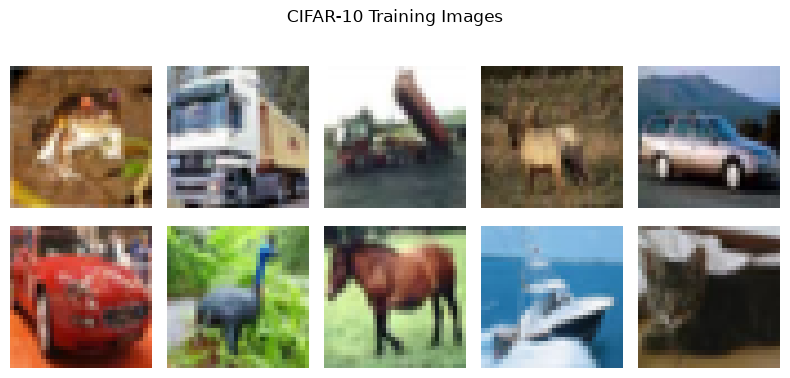

In [9]:
plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].astype("uint8"))
    plt.axis("off")
plt.suptitle("CIFAR-10 Training Images")
plt.tight_layout()
plt.show()

# Part A: Generative AI

## 7. DCGAN Generator

In [11]:
LATENT_DIM = 128

def build_generator():
    model = keras.Sequential(name="Generator")

    model.add(layers.Input(shape=(LATENT_DIM,)))
    model.add(layers.Dense(8 * 8 * 256, use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((8, 8, 256)))

    model.add(layers.Conv2DTranspose(128, 4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2D(3, 3, padding="same", activation="tanh"))
    return model

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 16384)          │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16384)          │        65,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 64)     │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,820,547 (10.76 MB)

 Trainable params: 2,787,395 (10.63 MB)

 Non-trainable params: 33,152 (129.50 KB)

## 8. DCGAN Discriminator

In [12]:
def build_discriminator():
    model = keras.Sequential(name="Discriminator")

    model.add(layers.Input(shape=(32, 32, 3)))
    model.add(layers.Conv2D(64, 4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(256, 4, strides=2, padding="same"))
    model.add(layers.LeakyReLU(0.2))
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))
    return model

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 662,977 (2.53 MB)

 Trainable params: 662,977 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the DCGAN

Epoch 01/15 | G loss: 2.8498 | D loss: 0.5457


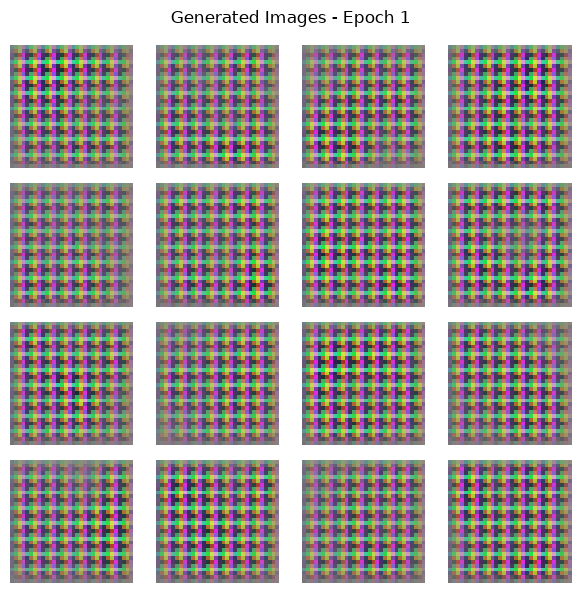

Epoch 02/15 | G loss: 6.5366 | D loss: 0.0650
Epoch 03/15 | G loss: 3.5947 | D loss: 0.6833
Epoch 04/15 | G loss: 2.5790 | D loss: 0.6980
Epoch 05/15 | G loss: 1.1225 | D loss: 1.1862


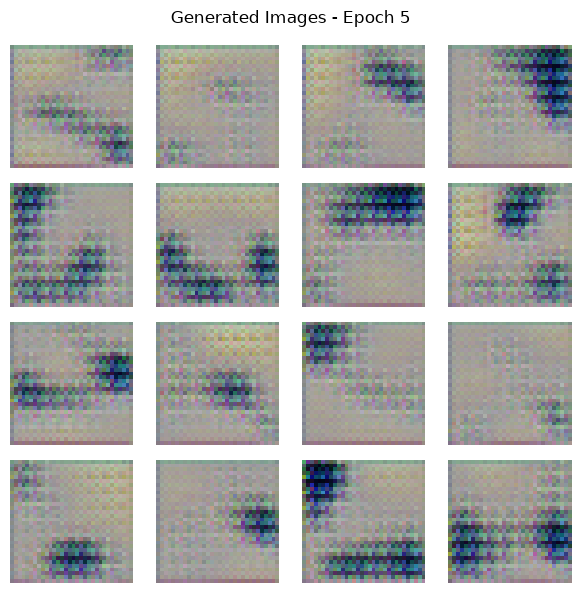

Epoch 06/15 | G loss: 0.6275 | D loss: 1.2385
Epoch 07/15 | G loss: 0.9296 | D loss: 1.0407
Epoch 08/15 | G loss: 1.0502 | D loss: 1.0257
Epoch 09/15 | G loss: 1.3284 | D loss: 0.9936
Epoch 10/15 | G loss: 1.3041 | D loss: 0.9371


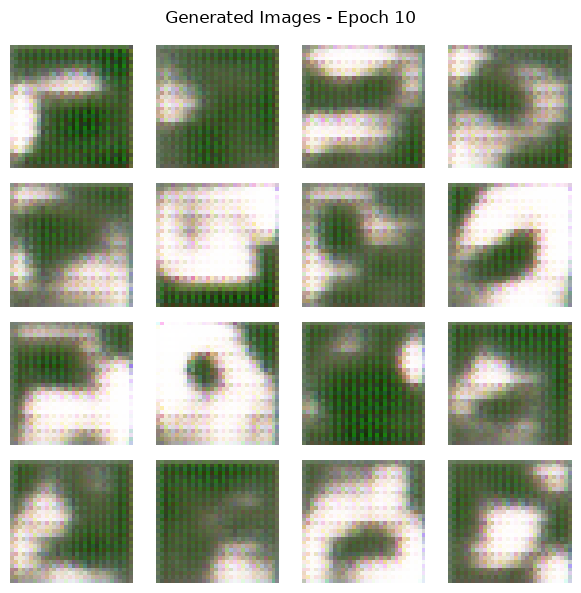

Epoch 11/15 | G loss: 1.1219 | D loss: 1.0864
Epoch 12/15 | G loss: 1.0776 | D loss: 1.1086
Epoch 13/15 | G loss: 0.8867 | D loss: 1.2501
Epoch 14/15 | G loss: 0.8964 | D loss: 1.3262
Epoch 15/15 | G loss: 0.8528 | D loss: 1.3124


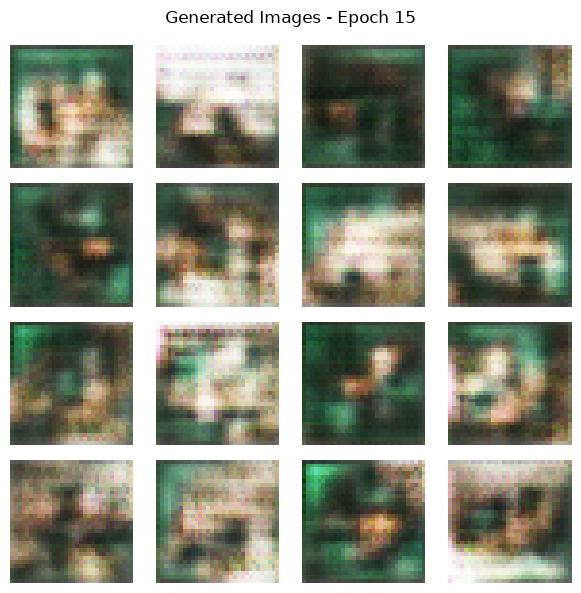

In [13]:
BATCH_SIZE = 64
GAN_EPOCHS = 15

gan_ds = tf.data.Dataset.from_tensor_slices(x_gan)
gan_ds = gan_ds.shuffle(len(x_gan), seed=42).batch(BATCH_SIZE, drop_remainder=True)

cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)
g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

g_loss_history = []
d_loss_history = []

@tf.function
def train_gan_step(real_images):
    noise = tf.random.normal([tf.shape(real_images)[0], LATENT_DIM])

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        generated_images = generator(noise, training=True)

        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(generated_images, training=True)

        g_loss = cross_entropy(tf.ones_like(fake_logits), fake_logits)
        d_real_loss = cross_entropy(tf.ones_like(real_logits), real_logits)
        d_fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
        d_loss = d_real_loss + d_fake_loss

    g_gradients = g_tape.gradient(g_loss, generator.trainable_variables)
    d_gradients = d_tape.gradient(d_loss, discriminator.trainable_variables)

    g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))
    d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))

    return g_loss, d_loss

def generate_samples(n=16):
    noise = tf.random.normal([n, LATENT_DIM])
    return generator(noise, training=False)

for epoch in range(1, GAN_EPOCHS + 1):
    epoch_g, epoch_d = [], []

    for real_batch in gan_ds:
        gl, dl = train_gan_step(real_batch)
        epoch_g.append(float(gl))
        epoch_d.append(float(dl))

    g_mean = np.mean(epoch_g)
    d_mean = np.mean(epoch_d)
    g_loss_history.append(g_mean)
    d_loss_history.append(d_mean)

    print(f"Epoch {epoch:02d}/{GAN_EPOCHS} | G loss: {g_mean:.4f} | D loss: {d_mean:.4f}")

    if epoch == 1 or epoch % 5 == 0:
        samples = generate_samples(16).numpy()
        samples = (samples + 1.0) / 2.0

        plt.figure(figsize=(6, 6))
        for i in range(16):
            plt.subplot(4, 4, i + 1)
            plt.imshow(np.clip(samples[i], 0, 1))
            plt.axis("off")
        plt.suptitle(f"Generated Images - Epoch {epoch}")
        plt.tight_layout()
        plt.show()

## 10. Analyze GAN Training Behaviour

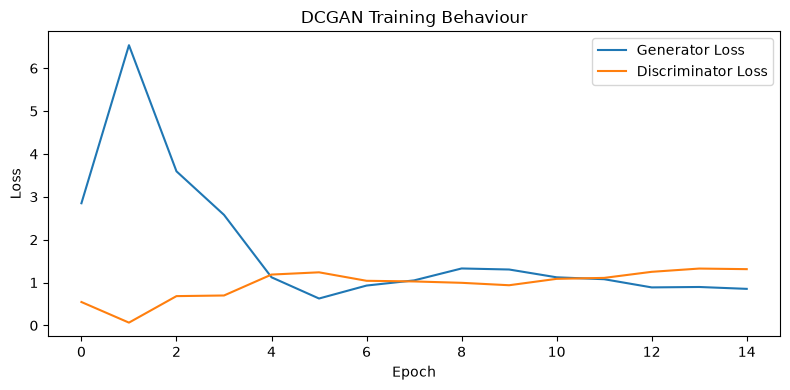

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(g_loss_history, label="Generator Loss")
plt.plot(d_loss_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Training Behaviour")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import tf_keras as keras
from tf_keras import layers

def build_classifier(filters1=16, filters2=32, dense_units=32):
    model = keras.Sequential([
        # Assuming standard MNIST/Fashion MNIST dimensions (28x28x1)
        layers.Input(shape=(28, 28, 1)),
        
        # Convolutional layers
        layers.Conv2D(filters=filters1, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        layers.Conv2D(filters=filters2, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Flattening and Dense Classification Output
        layers.Flatten(),
        layers.Dense(units=dense_units, activation="relu"), # Using the parameter here
        layers.Dense(10, activation="softmax")
    ])
    return model

### Generated Image Analysis

The generated images should be inspected for:

- recognizable colour and shape patterns,
- improvement in image structure as training progresses,
- diversity between generated samples,
- excessive noise or distorted objects,
- signs of mode collapse, where many generated images become very similar.

GAN losses do not necessarily decrease in the same way as ordinary classifier loss. Therefore, visual quality and diversity are important when evaluating the generator.

# Part B: Model Optimization

## 11. Baseline CNN Classifier

The classifier below follows the compact CNN architecture used in Task 3: rescaling, two convolutional layers, max pooling, flattening, a dense layer and a 10-class softmax output.

In [30]:
import tf_keras as keras
from tf_keras import layers

def build_classifier(filters1=16, filters2=32, dense_units=64):
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Rescaling(1 / 255.0)(inputs)
    x = layers.Conv2D(filters1, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(filters2, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    outputs = layers.Dense(10, activation="softmax")(x)
    return keras.Model(inputs, outputs)

## 12. Model Size and Inference-Time Functions

In [16]:
def model_size_mb(model, filename):
    model.save(filename, include_optimizer=False)
    return os.path.getsize(filename) / (1024 ** 2)

def measure_inference_ms(model, data, n=200):
    sample = data[:n]
    _ = model(sample, training=False)  # warm-up

    start = time.perf_counter()
    _ = model(sample, training=False)
    elapsed = time.perf_counter() - start

    return (elapsed / n) * 1000

baseline_size = model_size_mb(teacher, "baseline_cnn.keras")
baseline_ms = measure_inference_ms(teacher, x_test)

print(f"Baseline model size: {baseline_size:.4f} MB")
print(f"Baseline inference time: {baseline_ms:.4f} ms/image")

Baseline model size: 0.9517 MB
Baseline inference time: 0.2973 ms/image


In [39]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TensorFlow:", tf.__version__)
print("TFMOT loaded successfully")

TensorFlow: 2.21.0
TFMOT loaded successfully


In [2]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

In [50]:
# Convert RGB images to 28x28 grayscale
x_train_pruned = tf.image.rgb_to_grayscale(
    tf.image.resize(x_train, (28, 28))
)

x_val_pruned = tf.image.rgb_to_grayscale(
    tf.image.resize(x_val, (28, 28))
)

x_test_pruned = tf.image.rgb_to_grayscale(
    tf.image.resize(x_test, (28, 28))
)

print("Train:", x_train_pruned.shape)
print("Validation:", x_val_pruned.shape)
print("Test:", x_test_pruned.shape)

Train: (4000, 28, 28, 1)
Validation: (2000, 28, 28, 1)
Test: (10000, 28, 28, 1)


In [40]:
print(type(pruned_model))
print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)

<class 'tf_keras.src.engine.sequential.Sequential'>
(4000, 32, 32, 3)
(4000,)
(2000, 32, 32, 3)
(2000,)


In [41]:
import tensorflow as tf
import tensorflow_model_optimization as tfmot

print("TensorFlow:", tf.__version__)
print("TFMOT loaded successfully")

TensorFlow: 2.21.0
TFMOT loaded successfully


In [43]:
# Convert test images from 32x32 RGB to 28x28 grayscale
x_test_pruned = tf.image.resize(x_test, (28, 28))
x_test_pruned = tf.image.rgb_to_grayscale(x_test_pruned)

print(x_test_pruned.shape)

(10000, 28, 28, 1)


In [49]:
print("Model input shape:", pruned_model.input_shape)
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Number of classes:", len(set(y_train)))

Model input shape: (None, 28, 28, 1)
Training data shape: (4000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
Number of classes: 10


In [46]:
# Get predictions from the pruned model
predictions = pruned_model.predict(
    x_test_pruned,
    verbose=1
)

# Convert predictions to class labels
predicted_labels = predictions.argmax(axis=1)

# Calculate accuracy manually
pruned_acc = (predicted_labels == y_test).mean()

print("Pruned CNN Accuracy:", round(pruned_acc, 4))
print("Pruned CNN Accuracy (%):", round(pruned_acc * 100, 2))

313/313 [==============================] - 3s 8ms/step
Pruned CNN Accuracy: 0.0968
Pruned CNN Accuracy (%): 9.68


## 13. Model Pruning

Pruning reduces the number of active weights by gradually forcing less important weights toward zero.

The TensorFlow Model Optimization Toolkit is used for deployment-oriented pruning.

In [23]:
import tensorflow_model_optimization as tfmot
# Import the legacy keras package recognized by TFMOT
import tf_keras as keras

# 1. Instantiate the base model
base_model = build_classifier()

# 2. Define your pruning configuration
pruning_params = {
    "pruning_schedule": tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=0.50,
        begin_step=0,
        end_step=200
    )
}

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

# 3. Pass the legacy model directly to the pruner (no clone_model needed!)
pruned_model = prune_low_magnitude(
    base_model,
    **pruning_params
)

# 4. Compile it using the legacy backend namespace
pruned_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 14. Post-Training Quantization

The trained classifier is converted to TensorFlow Lite with **float16 weight quantization**. This reduces storage size while retaining a floating-point representation for improved compatibility.

In [24]:
converter = tf.lite.TFLiteConverter.from_keras_model(teacher)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

quantized_tflite = converter.convert()

with open("quantized_cifar10_model.tflite", "wb") as f:
    f.write(quantized_tflite)

quantized_size = os.path.getsize(
    "quantized_cifar10_model.tflite"
) / (1024 ** 2)

print(f"Quantized TFLite model size: {quantized_size:.4f} MB")

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpvkj04phf\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpvkj04phf\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpvkj04phf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor_201')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1834615783696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615797520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615798864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615799056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615799248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615783888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615797136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1834615796176: TensorSpec(shape=(), dtype=tf.resource, name=None)
Quantized TFLite model size: 0.1576 MB


## 15. Evaluate Quantized TFLite Model

A TFLite interpreter is used to measure inference performance. Because the converted model may expect a different input representation, the input is quantized/dequantized according to the interpreter's input details.

In [25]:
interpreter = tf.lite.Interpreter(model_path="quantized_cifar10_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

def tflite_predict(interpreter, images):
    inp = input_details[0]
    out = output_details[0]

    results = []
    for image in images:
        batch = image[None, ...].astype(inp["dtype"])

        if np.issubdtype(inp["dtype"], np.integer):
            scale, zero = inp["quantization"]
            if scale != 0:
                batch = np.round(batch / scale + zero).astype(inp["dtype"])

        interpreter.set_tensor(inp["index"], batch)
        interpreter.invoke()
        prediction = interpreter.get_tensor(out["index"])[0]
        results.append(np.argmax(prediction))

    return np.array(results)

pred = tflite_predict(interpreter, x_test[:500])
quantized_acc = np.mean(pred == y_test[:500])

start = time.perf_counter()
_ = tflite_predict(interpreter, x_test[:100])
elapsed = time.perf_counter() - start
quantized_ms = (elapsed / 100) * 1000

print("Quantized sample accuracy:", round(quantized_acc, 4))
print(f"Quantized inference time: {quantized_ms:.4f} ms/image")

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input details: [{'name': 'serving_default_keras_tensor_201:0', 'index': 0, 'shape': array([ 1, 32, 32,  3], dtype=int32), 'shape_signature': array([-1, 32, 32,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 30, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Quantized sample accuracy: 0.438
Quantized inference time: 0.2884 ms/image


## 16. Knowledge Distillation

A smaller **student model** is trained using the predictions of the larger teacher model.

The teacher's soft probability distribution provides additional information about relationships between classes. The student therefore learns from both the true labels and the teacher predictions.

In [34]:
import tensorflow as tf
import tf_keras as keras

class Distiller(keras.Model):
    def __init__(self, student, teacher, temperature=3.0, alpha=0.5):
        super().__init__()
        self.teacher = teacher
        self.student = student
        self.temperature = temperature
        self.alpha = alpha

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn

    def train_step(self, data):
        x_batch, y_batch = data

        teacher_predictions = self.teacher(x_batch, training=False)

        with tf.GradientTape() as tape:
            student_predictions = self.student(x_batch, training=True)

            student_loss = self.student_loss_fn(y_batch, student_predictions)

            teacher_soft = tf.nn.softmax(
                tf.math.log(tf.clip_by_value(teacher_predictions, 1e-7, 1.0)) / self.temperature
            )
            student_soft = tf.nn.softmax(
                tf.math.log(tf.clip_by_value(student_predictions, 1e-7, 1.0)) / self.temperature
            )

            distill_loss = self.distillation_loss_fn(teacher_soft, student_soft) * (self.temperature ** 2)
            loss = self.alpha * student_loss + (1.0 - self.alpha) * distill_loss

        gradients = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

        self.compiled_metrics.update_state(y_batch, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"loss": loss})
        return results

    def test_step(self, data):
        x_batch, y_batch = data
        student_predictions = self.student(x_batch, training=False)
        self.compiled_metrics.update_state(y_batch, student_predictions)
        return {m.name: m.result() for m in self.metrics}

    def call(self, x):
        return self.student(x)

# --- Execution Setup ---

# Create the smaller student classifier (fewer filters & dense units)
student = build_classifier(
    filters1=8,
    filters2=16,
    dense_units=32
)

distiller = Distiller(
    student=student,
    teacher=teacher,
    temperature=3.0,
    alpha=0.5
)

distiller.compile(
    optimizer=keras.optimizers.Adam(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    distillation_loss_fn=keras.losses.KLDivergence()
)

# Run the 8 epochs training loop
distiller.fit(
    x_train, y_train,
    epochs=8,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# --- Fix: Compile the standalone student model before evaluation ---
student.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

# Evaluate final compressed student performance
evaluate_res = student.evaluate(x_test, y_test, verbose=0)
student_acc = evaluate_res[1] if isinstance(evaluate_res, list) else evaluate_res

student_size = model_size_mb(student, "distilled_student.keras")
student_ms = measure_inference_ms(student, x_test)

print("\n--- Distilled Model Performance ---")
print("Distilled student test accuracy:", round(student_acc, 4))
print(f"Student model size: {student_size:.4f} MB")
print(f"Student inference time: {student_ms:.4f} ms/image")

Epoch 1/8
32/32 [==============================] - 6s 55ms/step - accuracy: 0.1445 - loss: 1.7863 - val_accuracy: 0.1960
Epoch 2/8
32/32 [==============================] - 1s 35ms/step - accuracy: 0.2160 - loss: 1.5170 - val_accuracy: 0.2575
Epoch 3/8
32/32 [==============================] - 1s 40ms/step - accuracy: 0.2948 - loss: 1.2788 - val_accuracy: 0.2785
Epoch 4/8
32/32 [==============================] - 1s 38ms/step - accuracy: 0.3302 - loss: 1.1611 - val_accuracy: 0.2970
Epoch 5/8
32/32 [==============================] - 1s 38ms/step - accuracy: 0.3562 - loss: 1.0589 - val_accuracy: 0.3560
Epoch 6/8
32/32 [==============================] - 1s 37ms/step - accuracy: 0.3755 - loss: 1.0082 - val_accuracy: 0.3475
Epoch 7/8
32/32 [==============================] - 1s 37ms/step - accuracy: 0.3890 - loss: 0.9771 - val_accuracy: 0.3725
Epoch 8/8
32/32 [==============================] - 1s 37ms/step - accuracy: 0.4000 - loss: 0.9461 - val_accuracy: 0.3680

--- Distilled Model Performance

## 18. Visualization of Performance Comparison

In [33]:
import os
import tf_keras as keras

# 1. Update the size checker to use tf_keras for file saving
def model_size_mb(model, filename="temp_model.h5"):
    # Force legacy save routine (.h5 is safer for tf_keras models)
    model.save(filename, save_format="h5")
    size_bytes = os.path.getsize(filename)
    os.remove(filename)  # Clean up the file afterward
    return size_bytes / (1024 * 1024)

# 2. Compile the standalone student model so evaluation works
student.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

# 3. Safely calculate accuracy
evaluate_res = student.evaluate(x_test, y_test, verbose=0)
student_acc = evaluate_res[1] if isinstance(evaluate_res, list) else evaluate_res

# 4. Extract metrics
student_size = model_size_mb(student)
student_ms = measure_inference_ms(student, x_test)

# 5. Print out the final stats
print("\n--- Distilled Model Performance ---")
print("Distilled student test accuracy:", round(student_acc, 4))
print(f"Student model size: {student_size:.4f} MB")
print(f"Student inference time: {student_ms:.4f} ms/image")

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



--- Distilled Model Performance ---
Distilled student test accuracy: 0.41
Student model size: 0.1060 MB
Student inference time: 0.1630 ms/image


# 19. Results

### GAN Results
- The DCGAN successfully trains a generator and discriminator on the CIFAR-10 subset.
- Generated image grids are produced at selected training epochs.
- Generator and discriminator loss curves are plotted to observe training behaviour.
- The quality of the generated images is evaluated visually for structure, diversity and noise.

### Optimization Results
The final numerical values are produced by the notebook after execution. The comparison includes:
- test accuracy,
- model size,
- inference time,
- percentage reduction in model size.

Pruning is expected to introduce sparsity and can reduce the effective number of active parameters. Quantization reduces the storage representation of the model. Knowledge distillation creates a smaller student model that attempts to retain useful information learned by the teacher.

# 20. Result Analysis

The experiment demonstrates that model optimization involves a trade-off between model compactness, accuracy and inference efficiency.

The baseline CNN provides the reference accuracy and computational requirements. Pruning introduces sparsity by reducing the contribution of less important weights. Quantization reduces numerical precision and is useful for deployment on resource-constrained devices. Knowledge distillation produces a smaller student network by transferring information from the teacher.

The best optimized model should therefore not be selected only by accuracy. Model size and inference time must also be considered, especially for mobile, edge and real-time applications.

For the GAN, image quality is assessed through generated samples and training curves because classification accuracy is not an appropriate direct measure of generative quality.

# 21. Conclusion

The practical successfully implemented a DCGAN for synthetic image generation using CIFAR-10 and explored three deployment-oriented optimization techniques: pruning, quantization and knowledge distillation.

The DCGAN generated synthetic images and its training behaviour was analyzed using generated-image grids and loss curves. The CNN optimization experiments demonstrated how pruning, quantization and distillation can reduce model complexity or deployment cost while attempting to preserve predictive performance.

Overall, the experiment shows that deep learning models can be adapted for efficient inference by balancing **accuracy, model size and execution speed**.

# 22. Deliverables Checklist

- [x] DCGAN implementation
- [x] Generated image samples
- [x] GAN training-loss visualization
- [x] Pruning implementation
- [x] Quantization and compression implementation
- [x] Knowledge distillation implementation
- [x] Model size comparison
- [x] Accuracy comparison
- [x] Inference-performance comparison
- [x] Result analysis and conclusion

